# **Exploratory Data Analysis**

In [ ]:
import os
import gc
import glob
import shutil
import zipfile

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=8249df444802f4a4bcd16f7eff63033db172df90aa2c86575e8309d4aefb2f1f
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/thesis_data/output/panel_cleaned.csv"
df= pd.read_csv(path,low_memory=False)

**Analyzing the Data and Checking Missing Values...**


In [ ]:
print(f"Shape:{df.shape} (#rows x #columns)")
print(" ")
print("Data Type")
print(df.dtypes)
print(df.describe().T)
print(" ")
print("Checking Missing Values:")
print(df.isnull().sum())
print(f" ")

Shape:(3846097, 25) (#rows x #columns)
 
Data Type
loan_sequence_number           object
loan_age                      float64
current_upb                   float64
current_interest_rate         float64
estimated_ltv                 float64
borrower_assistance_status     object
credit_score                  float64
first_time_homebuyer          float64
occupancy_status_orig          object
original_dti                  float64
original_ltv                  float64
interest_rate                 float64
loan_purpose_orig              object
loan_term                     float64
num_borrowers                 float64
loan_amount                   float64
current_upb_delta             float64
bd_pct                        float64
bd_pct_trend                  float64
estimated_ltv_trend           float64
current_upb_trend             float64
FirstDefaultAge               float64
sex_bin_loan                  float64
race_bin_loan                 float64
age_bin_loan                  float64

The dataset contains 100,000 unique loans.

The default rate at loan level is 13.64%,
confirming a strong class imbalance (~1:6).

**Univariate Analysis...**

In [61]:
df["Ever_default"] = df["FirstDefaultAge"].notna().astype(int)


loan_level = df.drop_duplicates("loan_sequence_number")

print(f"Defaulted loans:     {loan_level['ever_default'].sum():,}")
print(f"Non-defaulted loans: {(loan_level['ever_default'] == 0).sum():,}")
print(f"Default rate:        {loan_level['ever_default'].mean():.2%}")

Defaulted loans:     13,638
Non-defaulted loans: 86,362
Default rate:        13.64%


Default rate: 15.49%


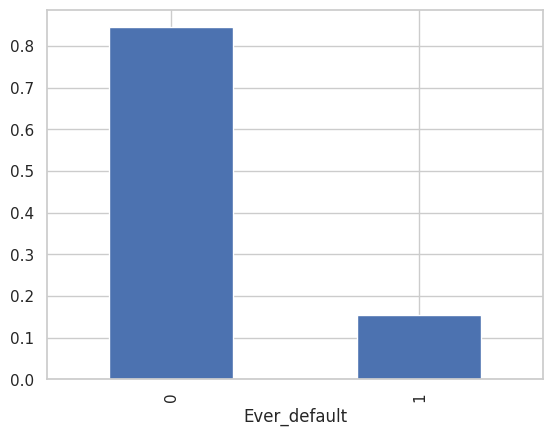

In [56]:
df["Ever_default"] = np.where(df["FirstDefaultAge"].isna(), 0, 1)
df["Ever_default"].value_counts(normalize=True).plot(kind="bar")

print(f"Default rate: {df['Ever_default'].mean():.2%}")

=== LOAN_AGE ===


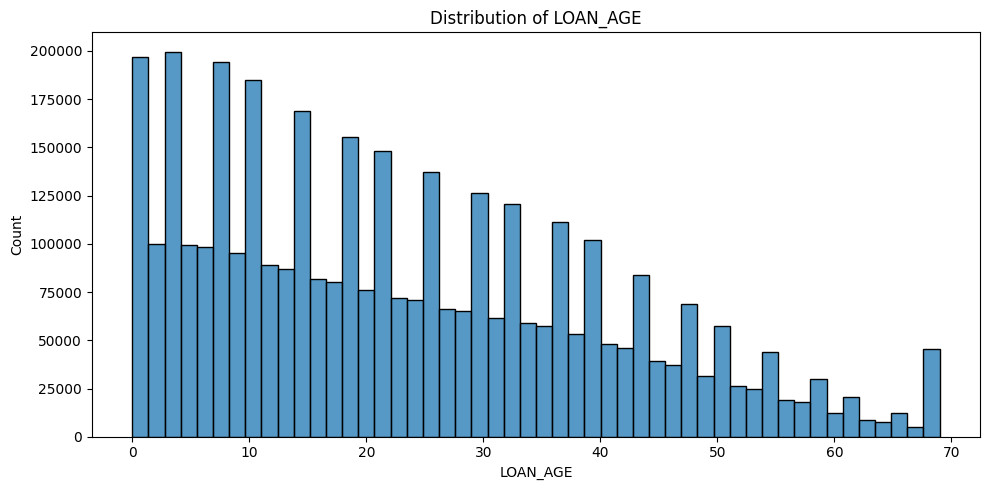

=== CREDIT_SCORE ===


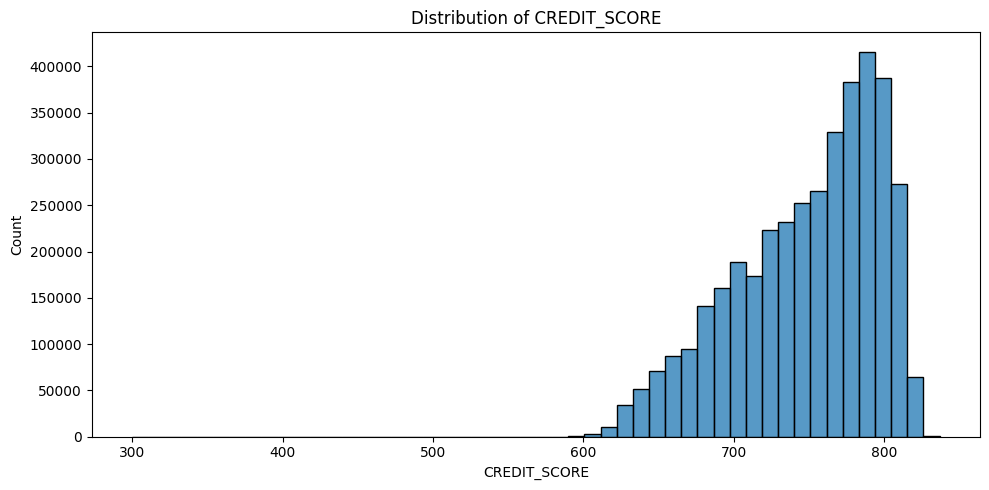

=== ORIGINAL_DTI ===


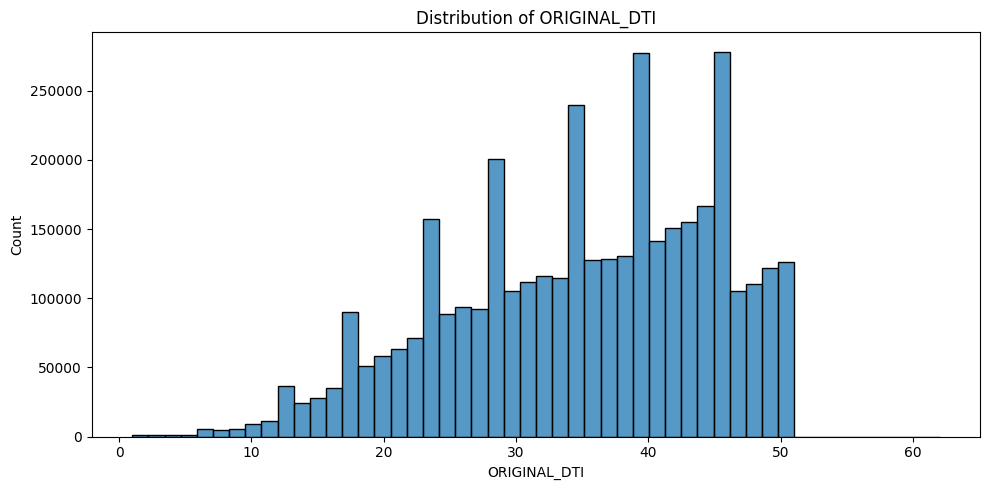

=== ORIGINAL_LTV ===


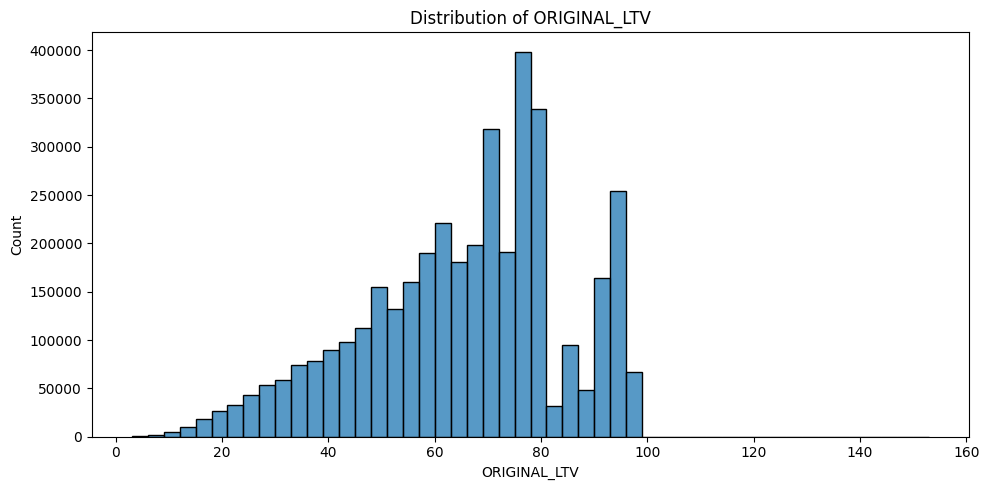

=== INTEREST_RATE ===


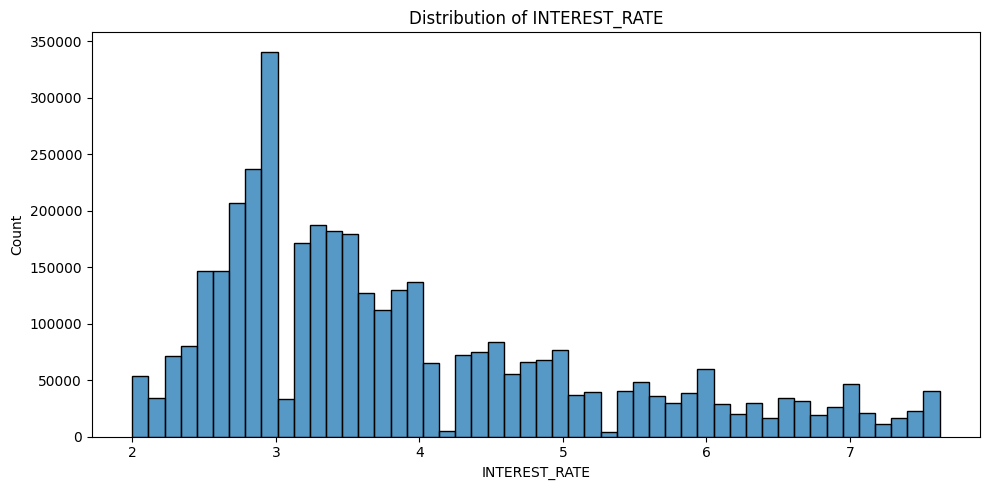

=== LOAN_TERM ===


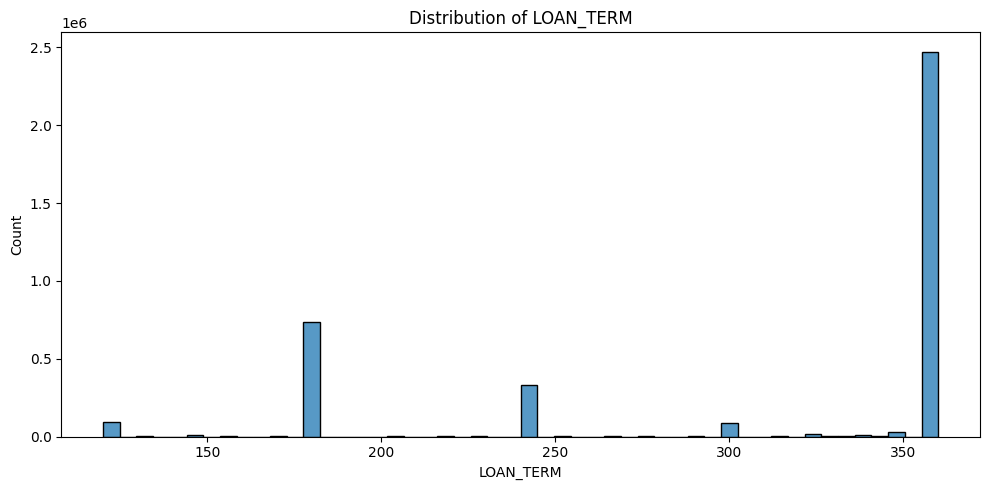

=== LOAN_AMOUNT ===


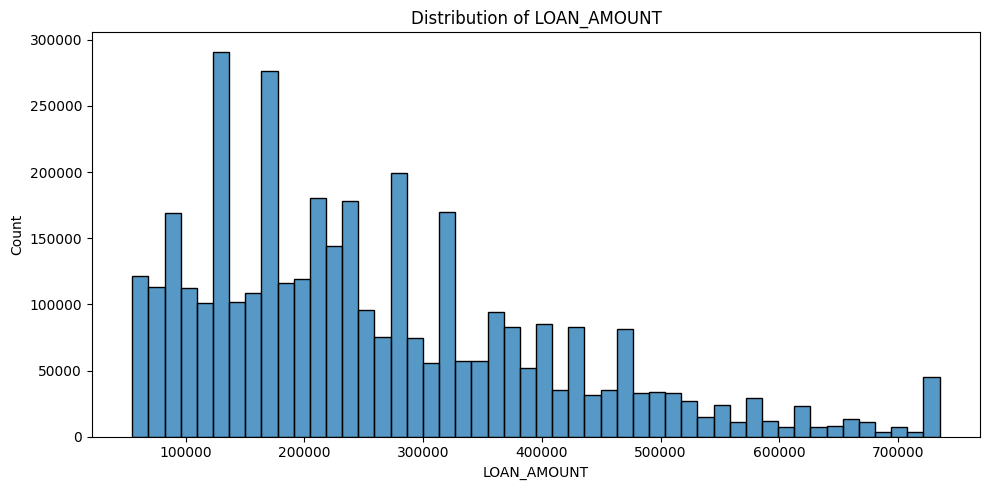

=== CURRENT_UPB ===


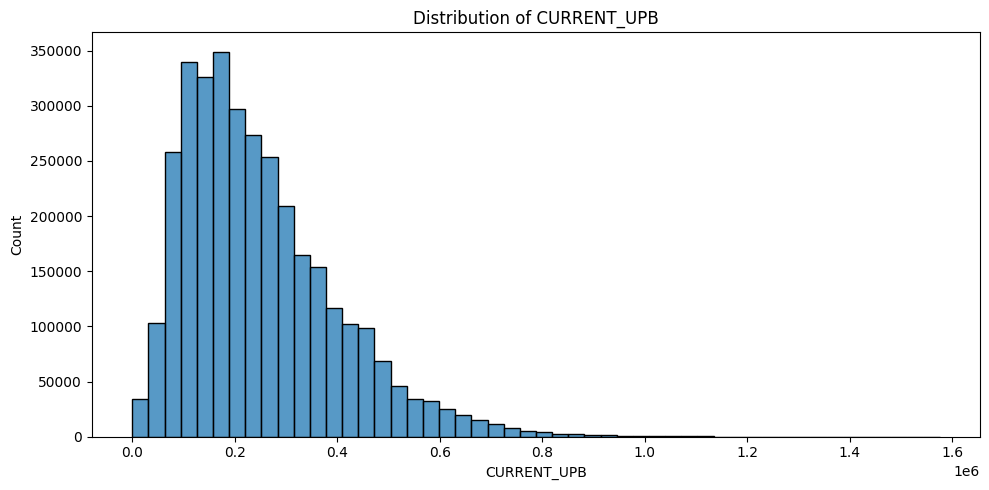

=== CURRENT_INTEREST_RATE ===


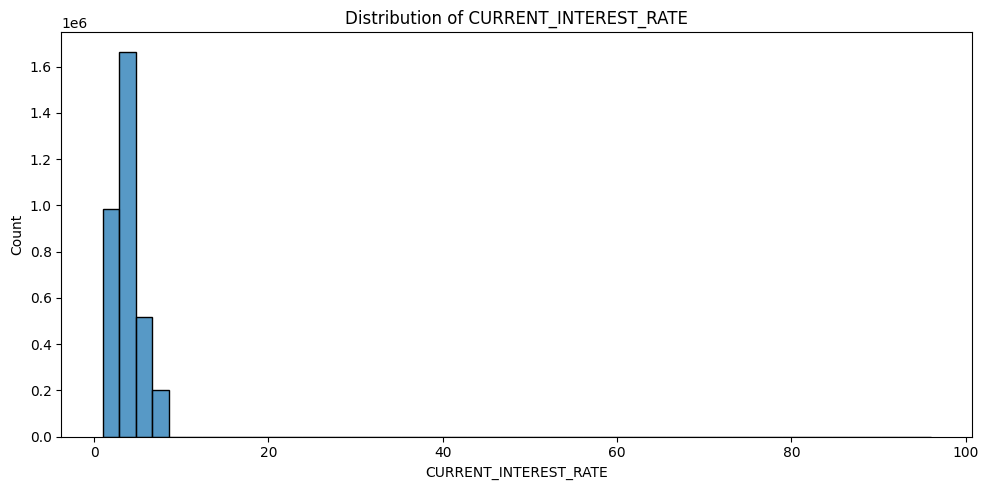

=== ESTIMATED_LTV ===


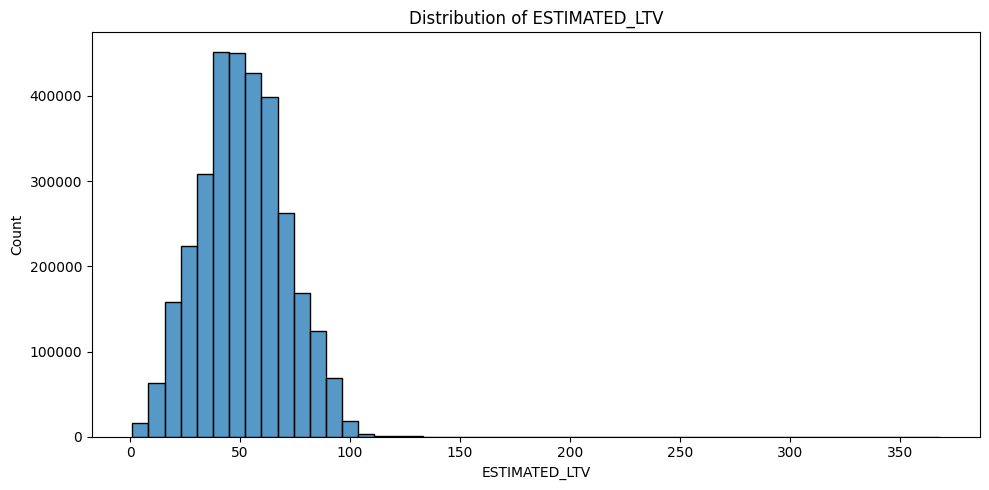

=== CURRENT_UPB_DELTA ===


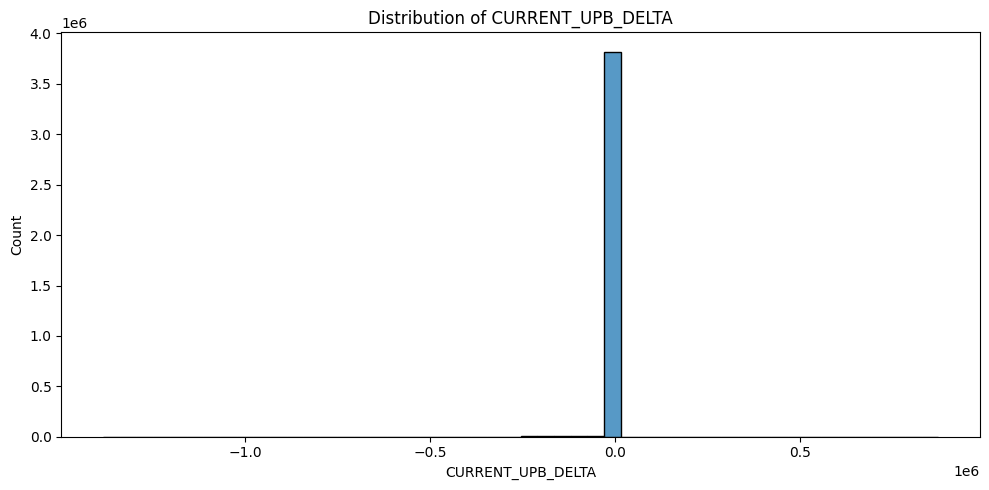

=== BD_PCT ===


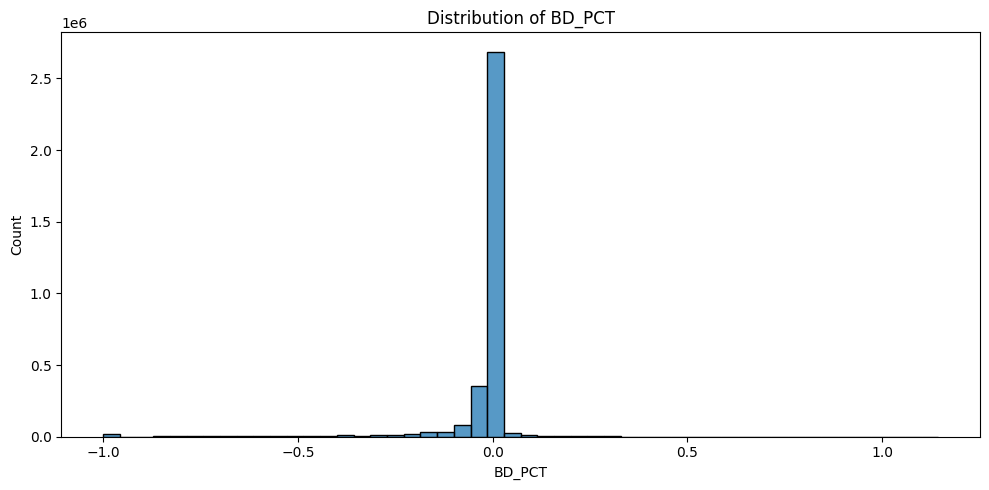

=== FIRSTDEFAULTAGE ===


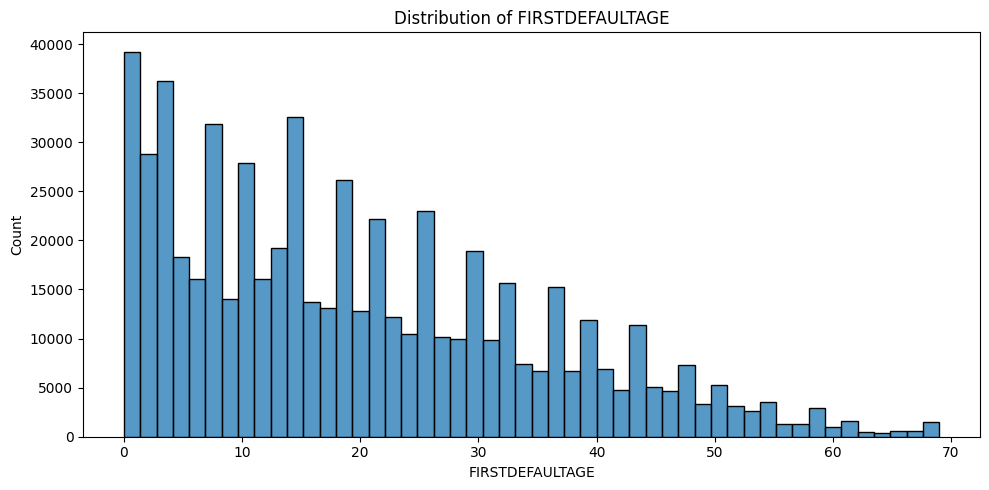

In [ ]:
hystogram_columns=[ 'loan_age',
    'credit_score',
    'original_dti',
    'original_ltv',
    'interest_rate',
    'loan_term',
    'loan_amount',
    'current_upb',
    'current_interest_rate',
    'estimated_ltv',
    'current_upb_delta',
    'bd_pct',
    'FirstDefaultAge'
]

for column in hystogram_columns:
  tag_name=column.upper()
  print(f"=== {tag_name} ===")
  fig, ax = plt.subplots(figsize=(10, 5))

  sns.histplot(data=df, x=column, bins=50, ax=ax)

  ax.set_title(f"Distribution of {tag_name}")
  ax.set_xlabel(f"{tag_name}")
  ax.set_ylabel("Count")

  plt.tight_layout()
  plt.show()

Numeric variables show right-skewed distributions for loan_amount, current_upb,
and FirstDefaultAge. credit_score and original_ltv show more concentrated distributions.


=== BORROWER_ASSISTANCE_STATUS ===


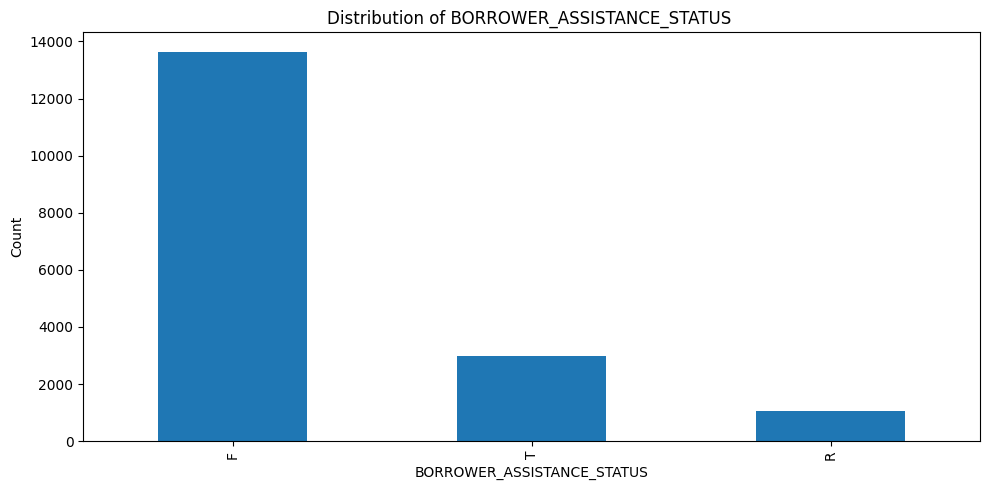

=== FIRST_TIME_HOMEBUYER ===


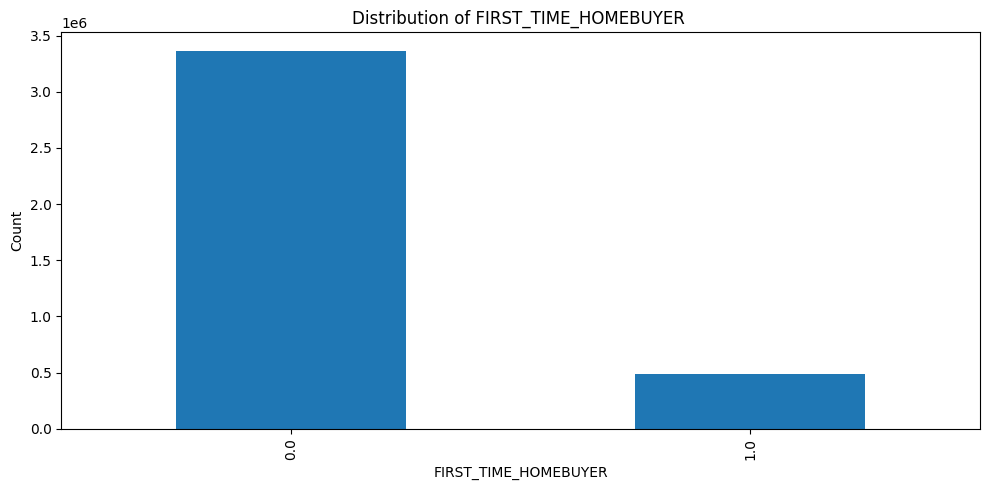

=== OCCUPANCY_STATUS_ORIG ===


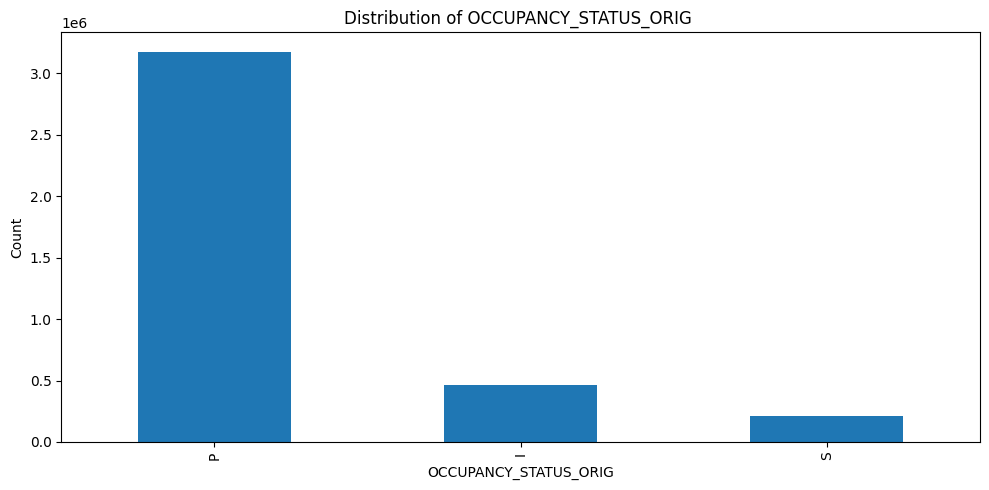

=== LOAN_PURPOSE_ORIG ===


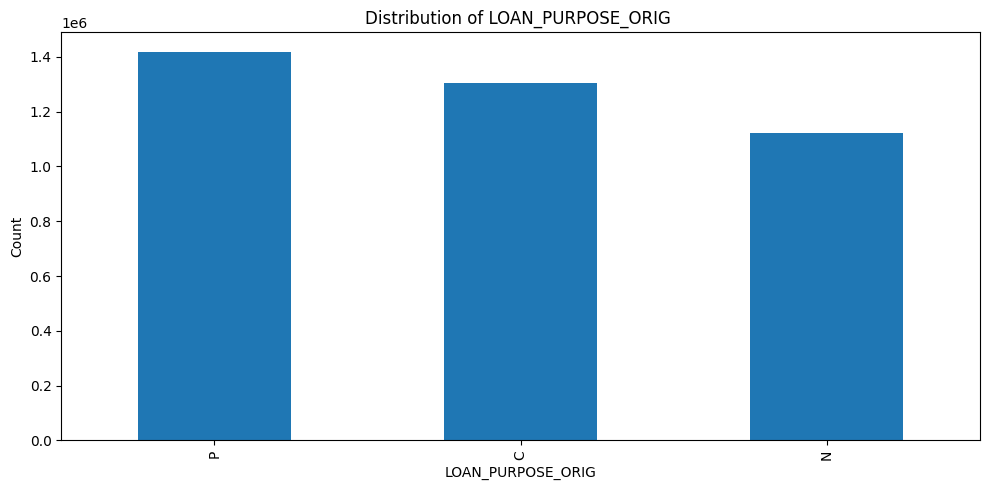

=== NUM_BORROWERS ===


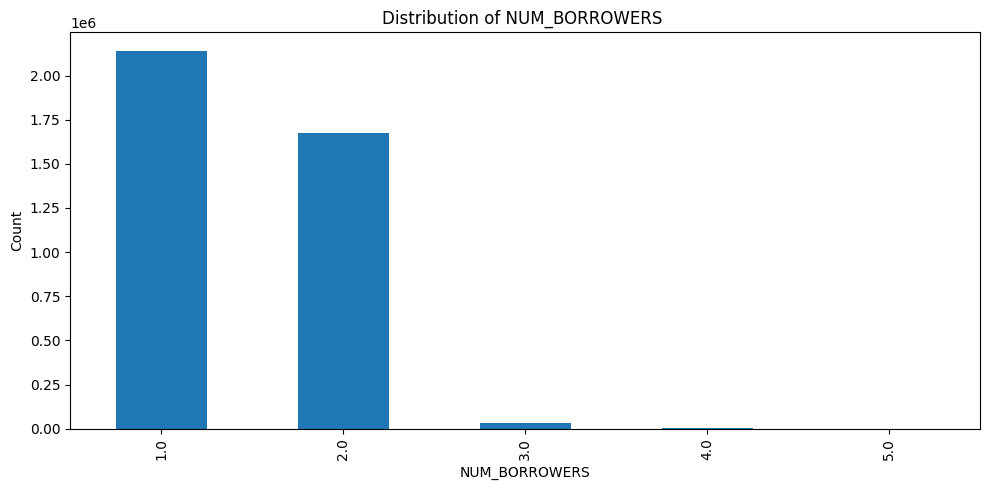

In [ ]:
barplot_columns=["borrower_assistance_status", "first_time_homebuyer", "occupancy_status_orig", "loan_purpose_orig","num_borrowers"]


for column in barplot_columns:
  tag_name=column.upper()
  print(f"=== {tag_name} ===")
  fig, ax = plt.subplots(figsize=(10, 5))

  df[column].value_counts().plot(kind="bar", ax=ax)

  ax.set_title(f"Distribution of {tag_name} ")
  ax.set_xlabel(f"{tag_name}")
  ax.set_ylabel("Count")

  plt.tight_layout()
  plt.show()



=== SEX_BIN_LOAN ===


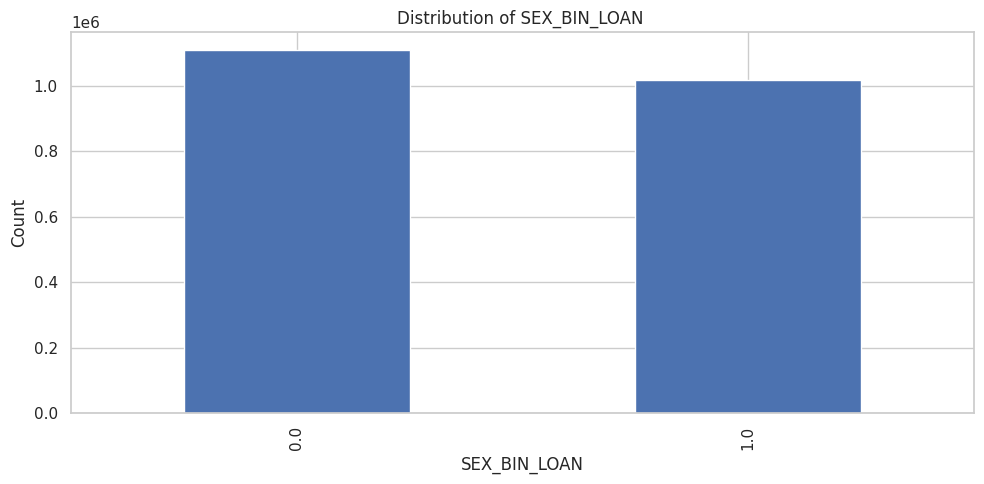

=== AGE_BIN_LOAN ===


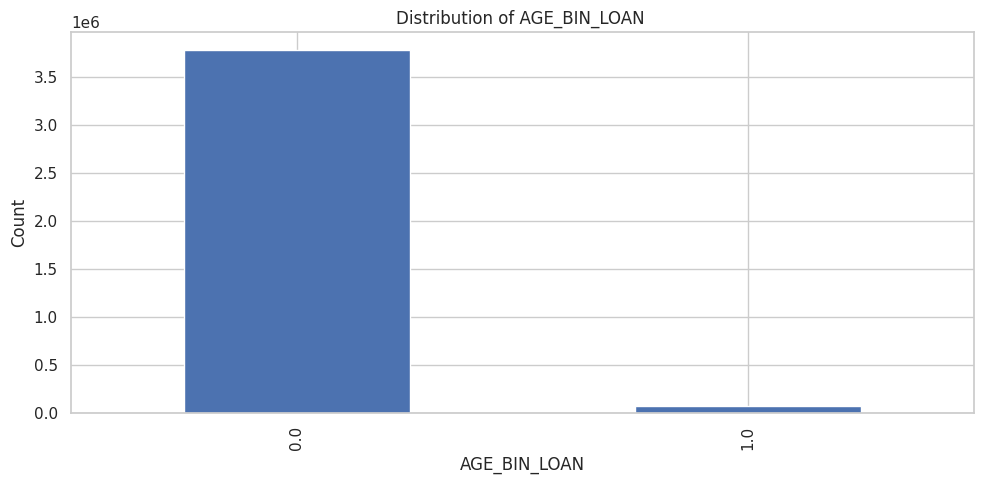

=== RACE_BIN_LOAN ===


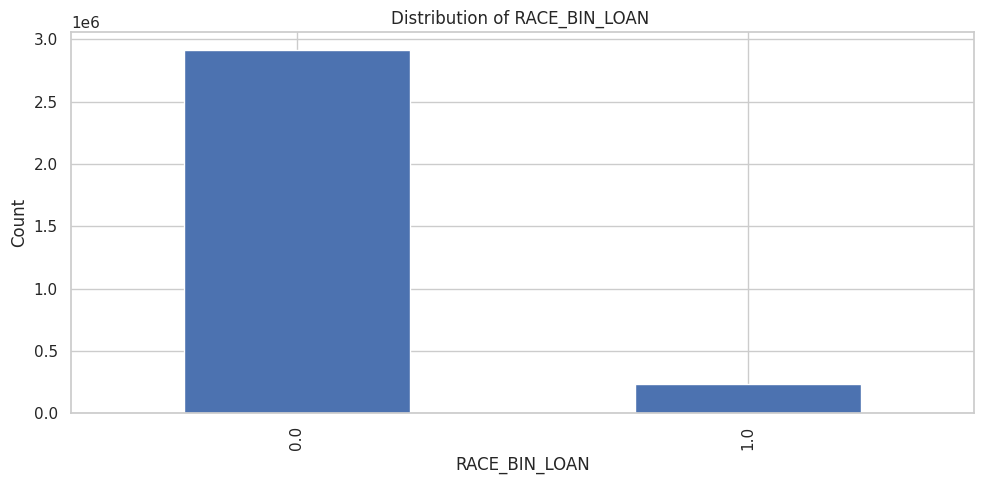

In [ ]:
barplot_columns_demo=["sex_bin_loan", "age_bin_loan", "race_bin_loan",]


for column in barplot_columns_demo:
  tag_name=column.upper()
  print(f"=== {tag_name} ===")
  fig, ax = plt.subplots(figsize=(10, 5))

  df[column].value_counts().plot(kind="bar", ax=ax)

  ax.set_title(f"Distribution of {tag_name} ")
  ax.set_xlabel(f"{tag_name}")
  ax.set_ylabel("Count")

  plt.tight_layout()
  plt.show()



Most loans are primary occupancy (P) and purchase purpose (P).


Demographics show strong imbalance: privileged groups (Male/Joint, White/Asian, Adult)
represent the majority of the sample.

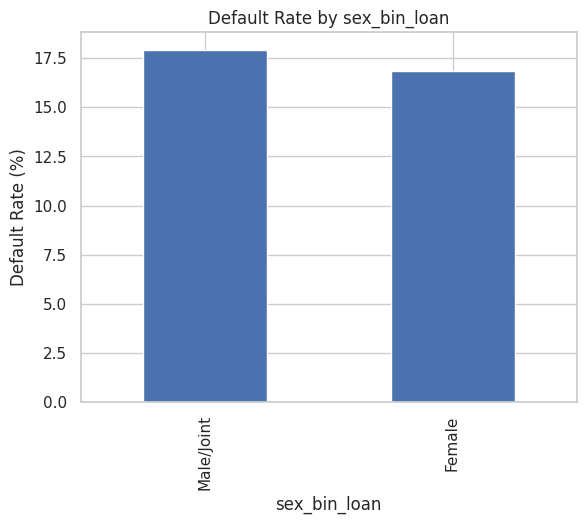

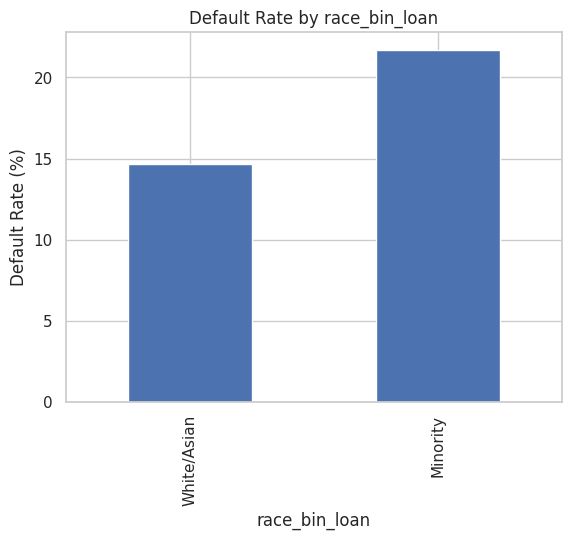

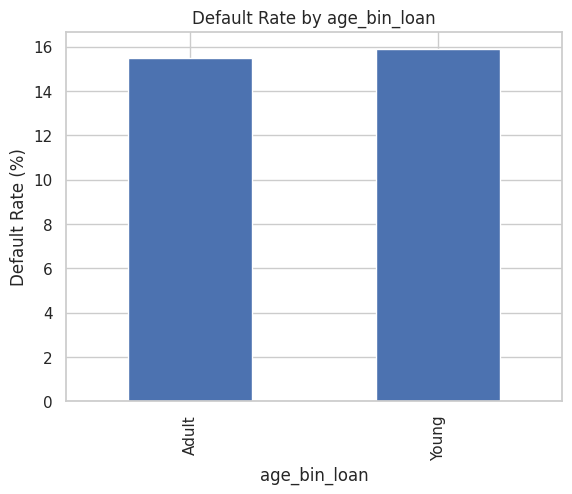

In [71]:
for demo, labels in [
    ("sex_bin_loan",  {0: "Male/Joint", 1: "Female"}),
    ("race_bin_loan", {0: "White/Asian", 1: "Minority"}),
    ("age_bin_loan",  {0: "Adult", 1: "Young"}),
]:
    dr = df.groupby(demo)["Ever_default"].mean() * 100
    dr.index = dr.index.map(labels)
    dr.plot(kind="bar", title=f"Default Rate by {demo}")
    plt.ylabel("Default Rate (%)")
    plt.show()

Discriminated groups show higher default rates in the case of
Minority vs White/Asian, Young vs Adult, while a fair situation exists for Sex.



**Bivariate Analysis..**

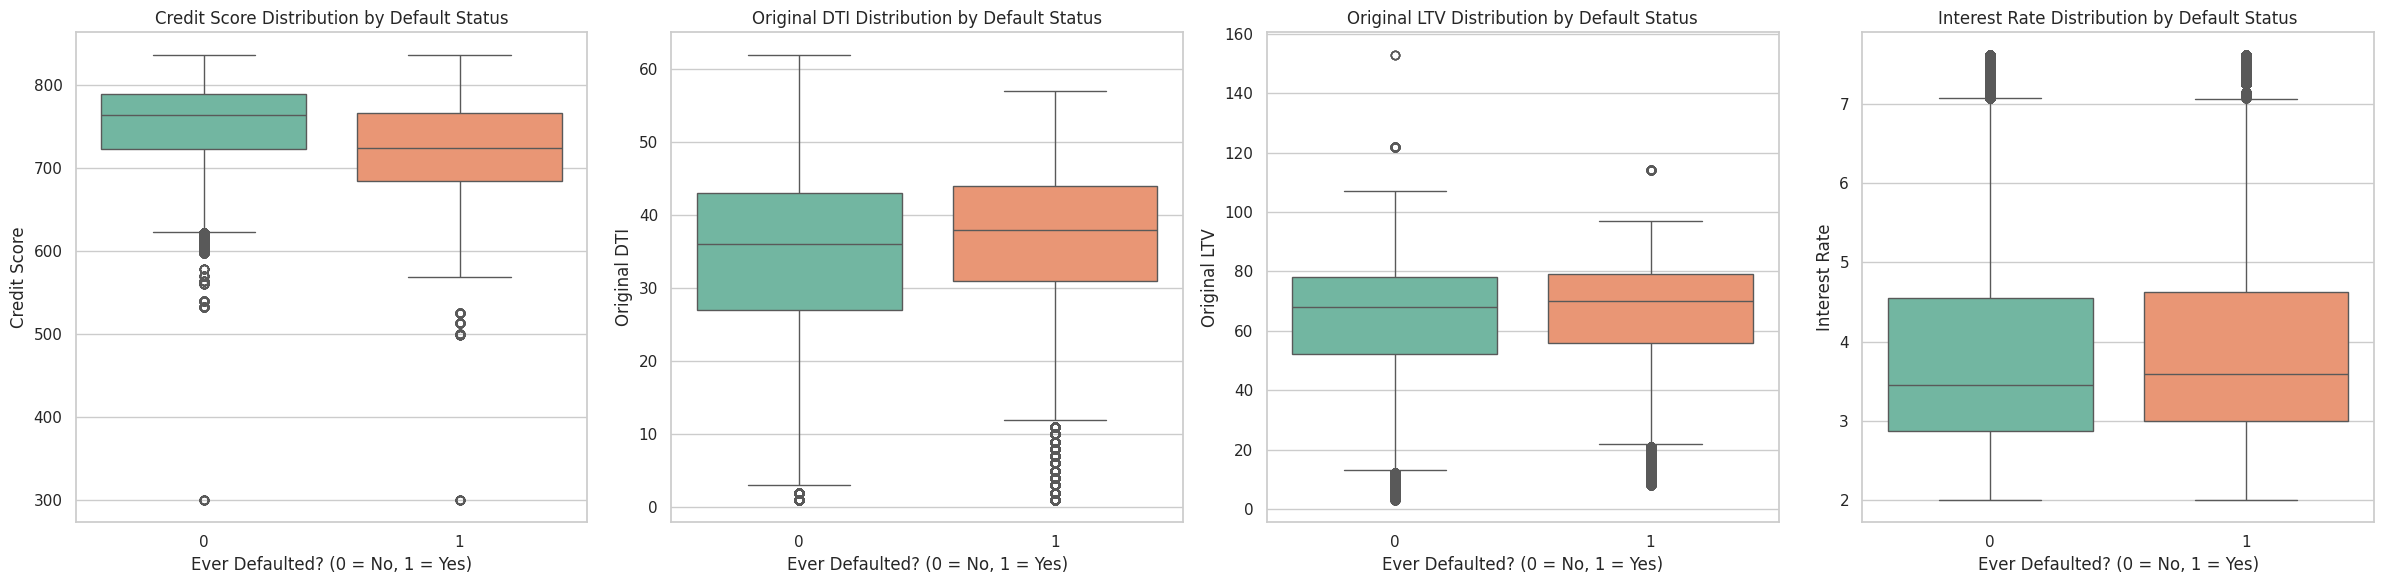

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


sns.set_theme(style="whitegrid")



mask1 = df[["credit_score", "Ever_default"]].dropna()
mask2 = df[["original_dti", "Ever_default"]].dropna()
mask3 = df[["original_ltv", "Ever_default"]].dropna()
mask4 = df[["interest_rate", "Ever_default"]].dropna()


fig, axes = plt.subplots(1, 4, figsize=(24, 6))


sns.boxplot(
    data=mask1, x="Ever_default", y="credit_score", ax=axes[0], palette="Set2", hue="Ever_default", legend=False
)
axes[0].set_title("Credit Score Distribution by Default Status")
axes[0].set_xlabel("Ever Defaulted? (0 = No, 1 = Yes)")
axes[0].set_ylabel("Credit Score")


sns.boxplot(
    data=mask2, x="Ever_default", y="original_dti", ax=axes[1], palette="Set2", hue="Ever_default", legend=False
)
axes[1].set_title("Original DTI Distribution by Default Status")
axes[1].set_xlabel("Ever Defaulted? (0 = No, 1 = Yes)")
axes[1].set_ylabel("Original DTI")


sns.boxplot(
    data=mask3, x="Ever_default", y="original_ltv", ax=axes[2], palette="Set2", hue="Ever_default", legend=False
)
axes[2].set_title("Original LTV Distribution by Default Status")
axes[2].set_xlabel("Ever Defaulted? (0 = No, 1 = Yes)")
axes[2].set_ylabel("Original LTV")


sns.boxplot(
    data=mask4, x="Ever_default", y="interest_rate", ax=axes[3], palette="Set2", hue="Ever_default", legend=False
)
axes[3].set_title("Interest Rate Distribution by Default Status")
axes[3].set_xlabel("Ever Defaulted? (0 = No, 1 = Yes)")
axes[3].set_ylabel("Interest Rate")


plt.tight_layout()
plt.show()

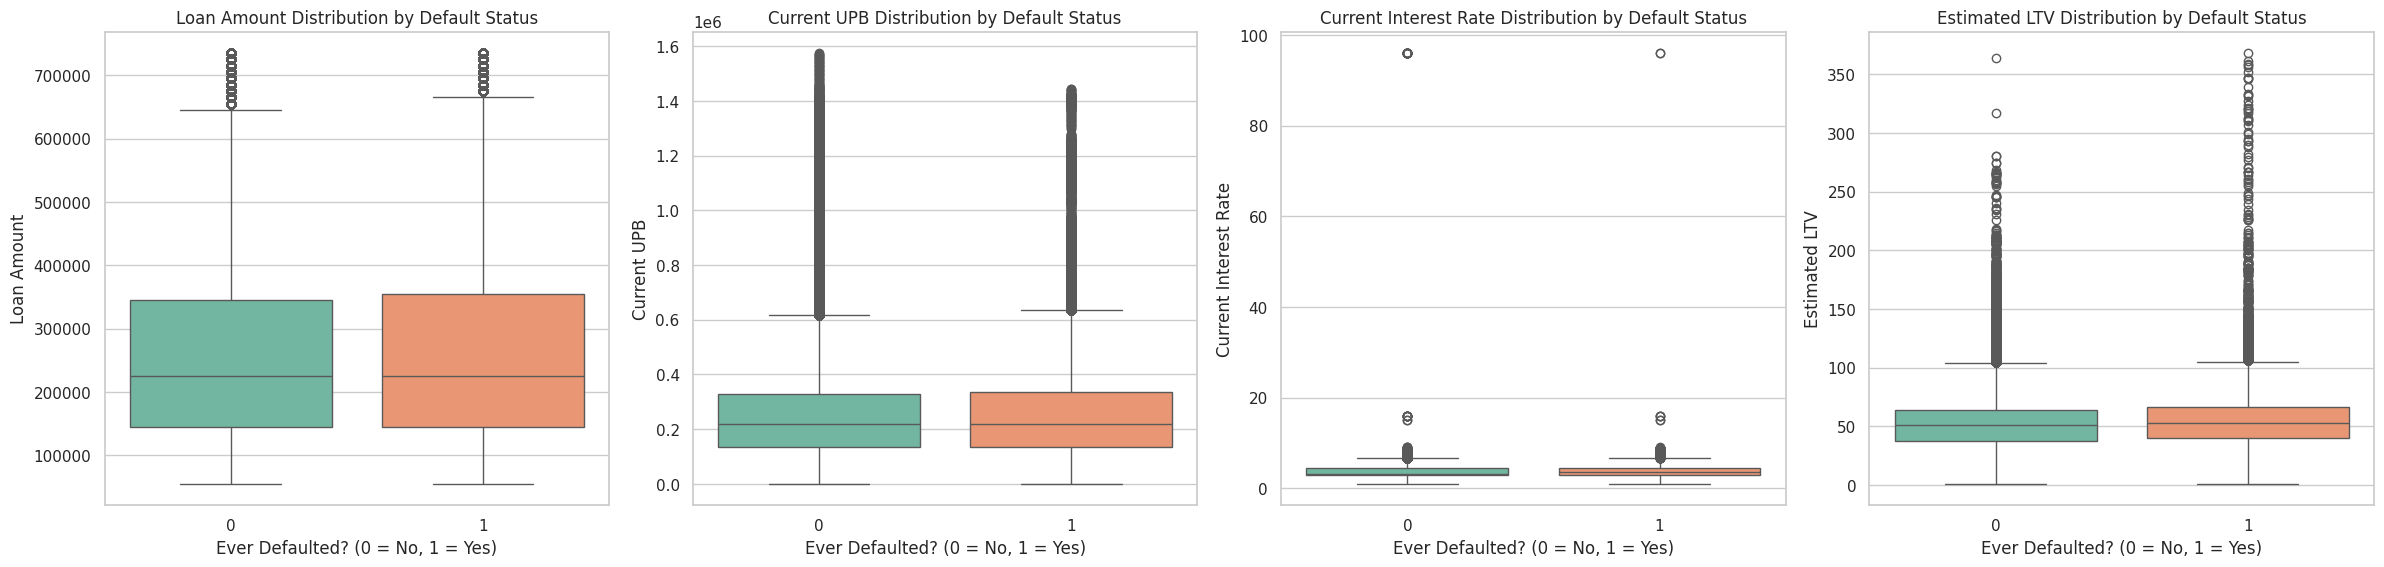

In [64]:
from IPython.core.interactiveshell import default
from pandas.core.api import DataFrame
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

mask1 = df[["loan_amount", "Ever_default"]].dropna()
mask2 = df[["current_upb", "Ever_default"]].dropna()
mask3 = df[["current_interest_rate", "Ever_default"]].dropna()
mask4 = df[["estimated_ltv", "Ever_default"]].dropna()

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

sns.boxplot(
    data=mask1, x="Ever_default", y="loan_amount", ax=axes[0], palette="Set2", hue="Ever_default", legend=False
)
axes[0].set_title("Loan Amount Distribution by Default Status")
axes[0].set_xlabel("Ever Defaulted? (0 = No, 1 = Yes)")
axes[0].set_ylabel("Loan Amount")

sns.boxplot(
    data=mask2, x="Ever_default", y="current_upb", ax=axes[1], palette="Set2", hue="Ever_default", legend=False
)
axes[1].set_title("Current UPB Distribution by Default Status")
axes[1].set_xlabel("Ever Defaulted? (0 = No, 1 = Yes)")
axes[1].set_ylabel("Current UPB")

sns.boxplot(
    data=mask3, x="Ever_default", y="current_interest_rate", ax=axes[2], palette="Set2", hue="Ever_default", legend=False
)
axes[2].set_title("Current Interest Rate Distribution by Default Status")
axes[2].set_xlabel("Ever Defaulted? (0 = No, 1 = Yes)")
axes[2].set_ylabel("Current Interest Rate")

sns.boxplot(
    data=mask4, x="Ever_default", y="estimated_ltv", ax=axes[3], palette="Set2", hue="Ever_default", legend=False
)
axes[3].set_title("Estimated LTV Distribution by Default Status")
axes[3].set_xlabel("Ever Defaulted? (0 = No, 1 = Yes)")
axes[3].set_ylabel("Estimated LTV")

plt.tight_layout()
plt.show()

Defaulted loans show lower credit_score, lightly higher DTI, and lightly higher LTV
compared to non-defaulted loans, confirming the predictive power of these variables.

**Multivariate Analysis - correlation**

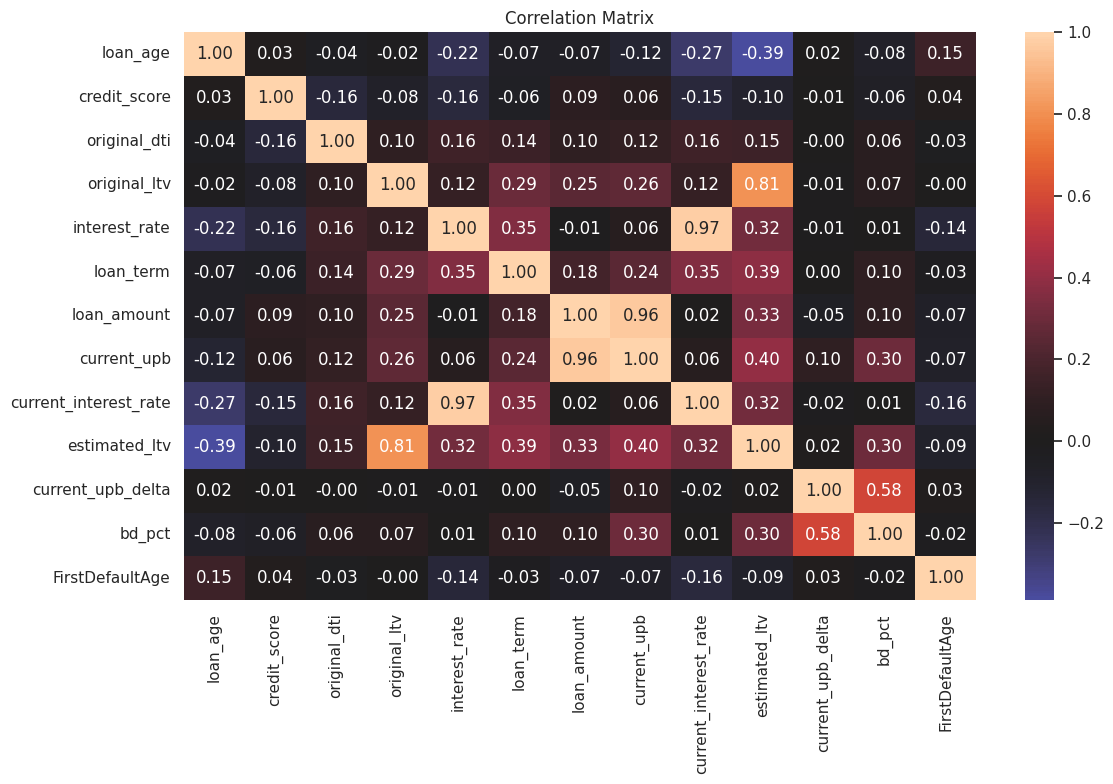

In [ ]:
num_cols =[ 'loan_age',
    'credit_score',
    'original_dti',
    'original_ltv',
    'interest_rate',
    'loan_term',
    'loan_amount',
    'current_upb',
    'current_interest_rate',
    'estimated_ltv',
    'current_upb_delta',
    'bd_pct',
    'FirstDefaultAge'
]


corr_matrix = df[num_cols].corr()


fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    ax=ax
)

ax.set_title(f"Correlation Matrix")
plt.tight_layout()
plt.show()

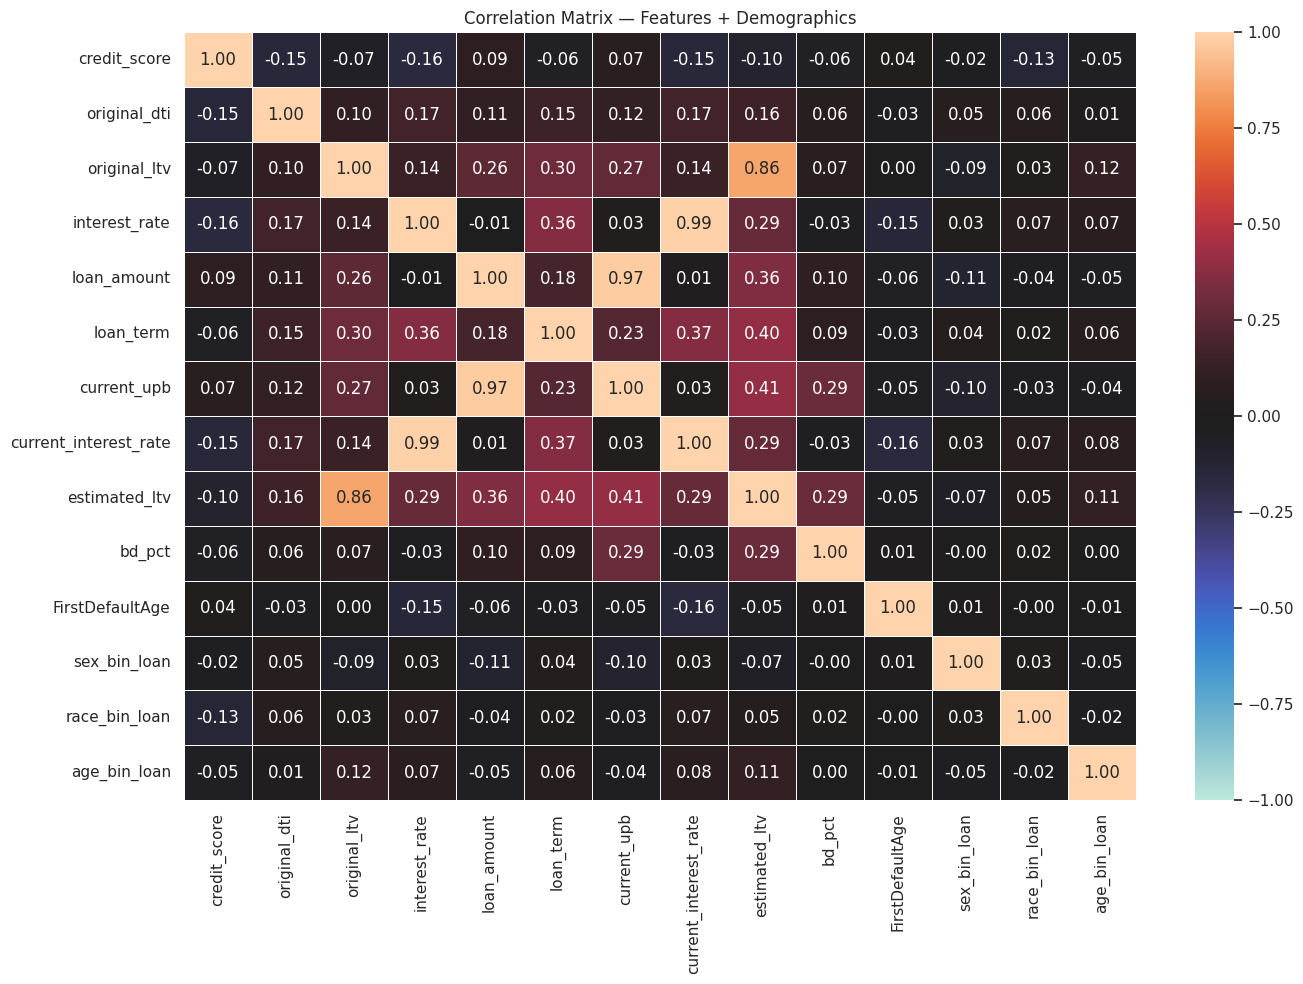

In [55]:
import seaborn as sns

demo_cols = ["sex_bin_loan", "race_bin_loan", "age_bin_loan"]
feature_cols = ["credit_score", "original_dti", "original_ltv",
                "interest_rate", "loan_amount", "loan_term",
                "current_upb", "current_interest_rate", "estimated_ltv",
                "bd_pct", "FirstDefaultAge"]

cols_to_plot = feature_cols + demo_cols

loan_age_median=(df["loan_age"]).median()

snap = df[df["loan_age"] == loan_age_median][cols_to_plot]

corr = snap.corr(method="pearson")

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Correlation Matrix — Features + Demographics")
plt.tight_layout()
plt.show()

Strong negative correlation between credit_score and FirstDefaultAge:
loans with lower scores default earlier. current_upb and loan_amount
are highly correlated and bd_pct shows moderate
positive correlation with estimated_ltv, consistent with its construction
as deviation from the theoretical amortization schedule.

**Presence of time-varying covariate...**

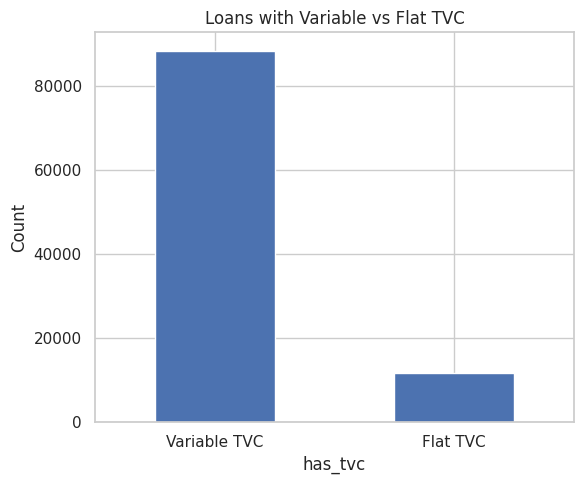

In [ ]:

loan_summary = df.groupby("loan_sequence_number").agg(
    upb_std  = ("current_upb",           "std"),
    rate_std = ("current_interest_rate",  "std"),
    ltv_std  = ("estimated_ltv",          "std"),
).reset_index()



loan_summary["has_tvc"] = (
    (loan_summary["upb_std"]  > 0) |
    (loan_summary["rate_std"] > 0) |
    (loan_summary["ltv_std"]  > 0)
)

fig, ax = plt.subplots(figsize=(6, 5))
loan_summary["has_tvc"].value_counts()\
    .rename({True: "Variable TVC", False: "Flat TVC"})\
    .plot(kind="bar", ax=ax)

ax.set_title(f"Loans with Variable vs Flat TVC")
ax.set_ylabel("Count")
ax.set_xticklabels(["Variable TVC", "Flat TVC"], rotation=0)
plt.tight_layout()
plt.show()

The majority of loans show variability in at least one time-varying covariate
(current_upb, current_interest_rate, estimated_ltv), confirming that the
longitudinal panel captures meaningful dynamic information beyond origination features.
This justifies the landmark model approach over a static snapshot.

**Cross-year analysis...**

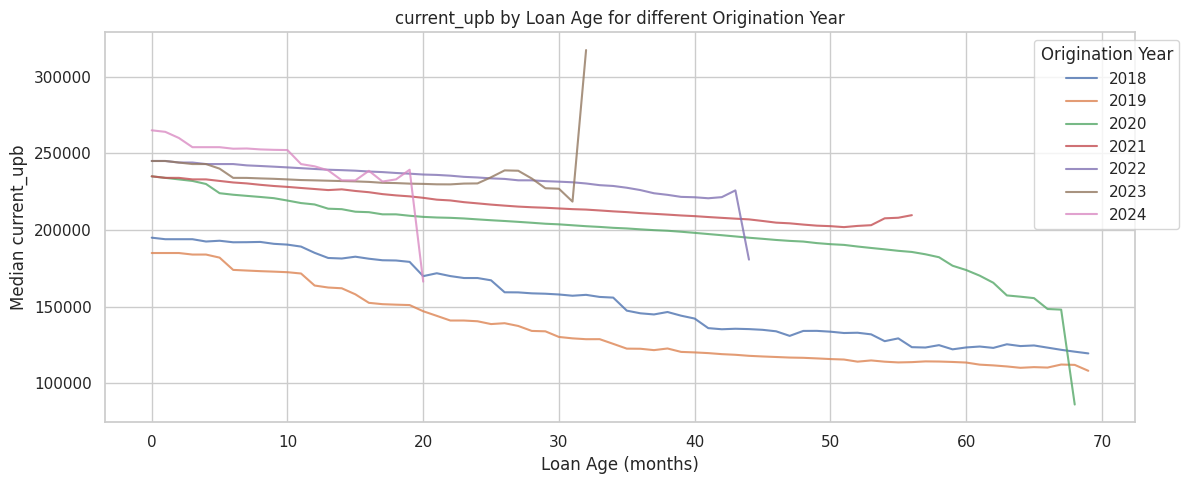

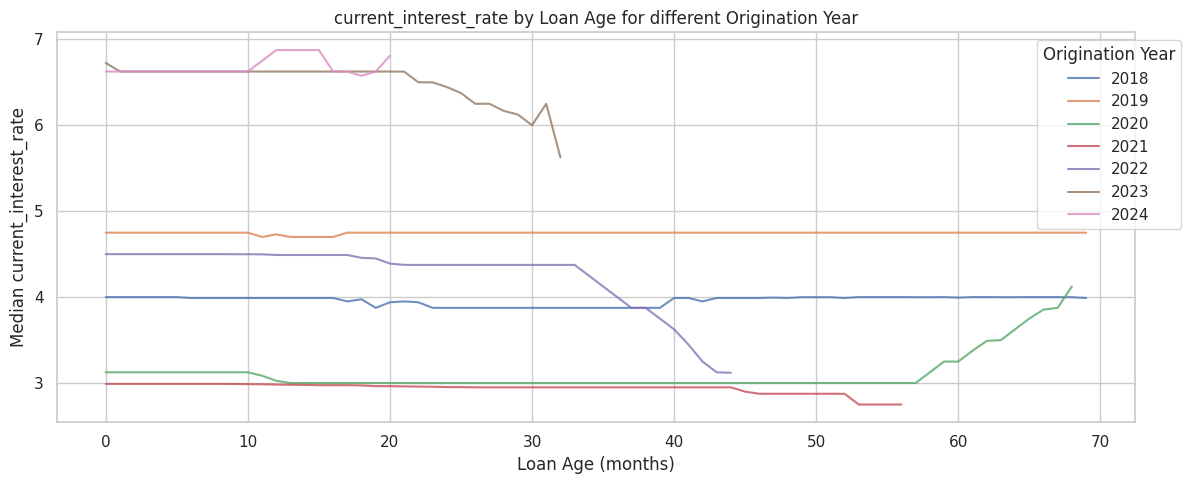

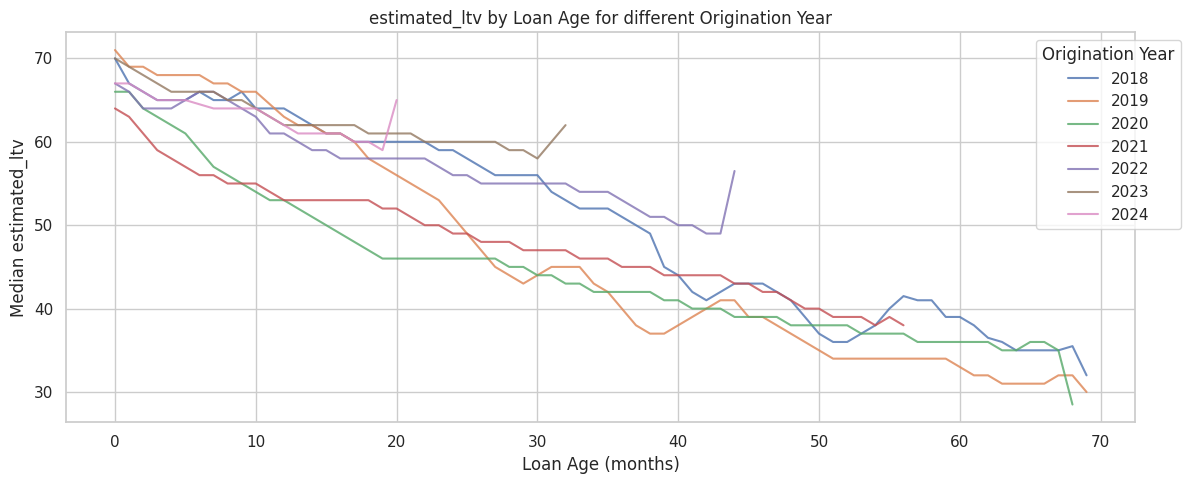

In [45]:
tvc_cols = ["current_upb", "current_interest_rate", "estimated_ltv"]

df["vintage_year"] = ("20"+df["loan_sequence_number"].astype(str).str[1:3]).astype(int)

for col in tvc_cols:
    fig, ax = plt.subplots(figsize=(12, 5))

    for year, group in df.groupby("vintage_year"):
        trend = group.groupby("loan_age")[col].median()
        trend.plot(ax=ax, label=str(year), alpha=0.8)

    ax.set_title(f"{col} by Loan Age for different Origination Year")
    ax.set_xlabel("Loan Age (months)")
    ax.set_ylabel(f"Median {col}")
    ax.legend(title="Origination Year", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

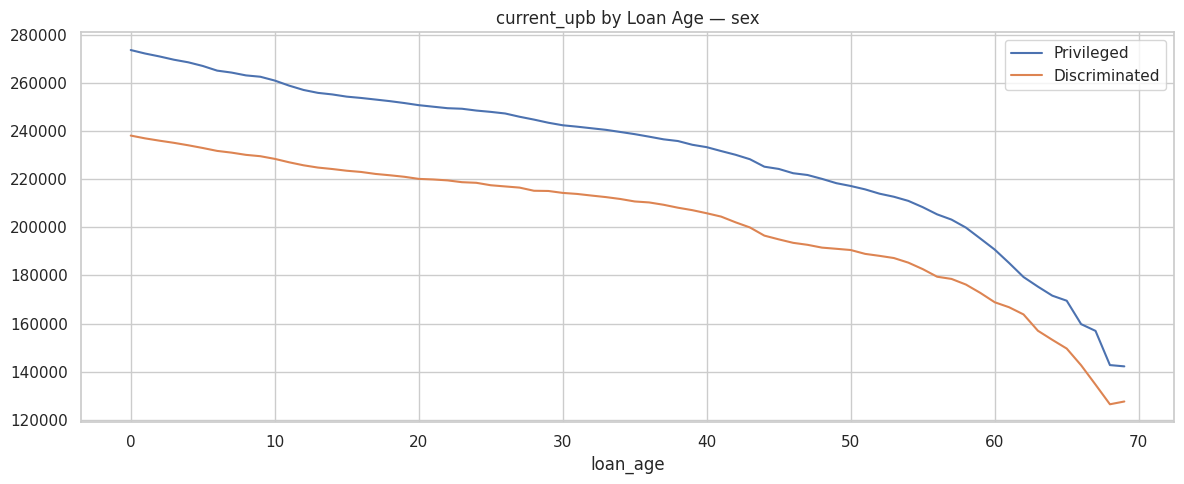

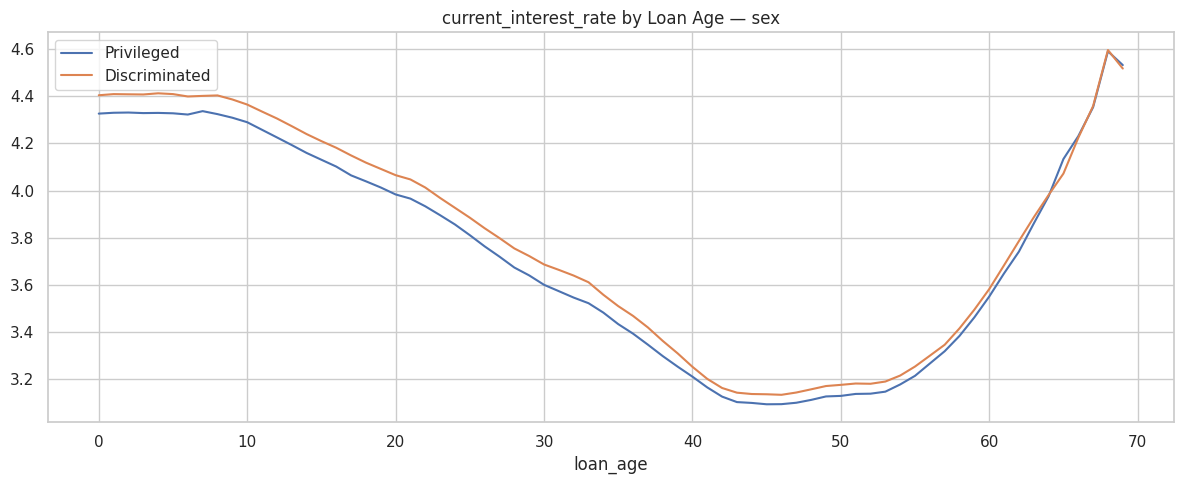

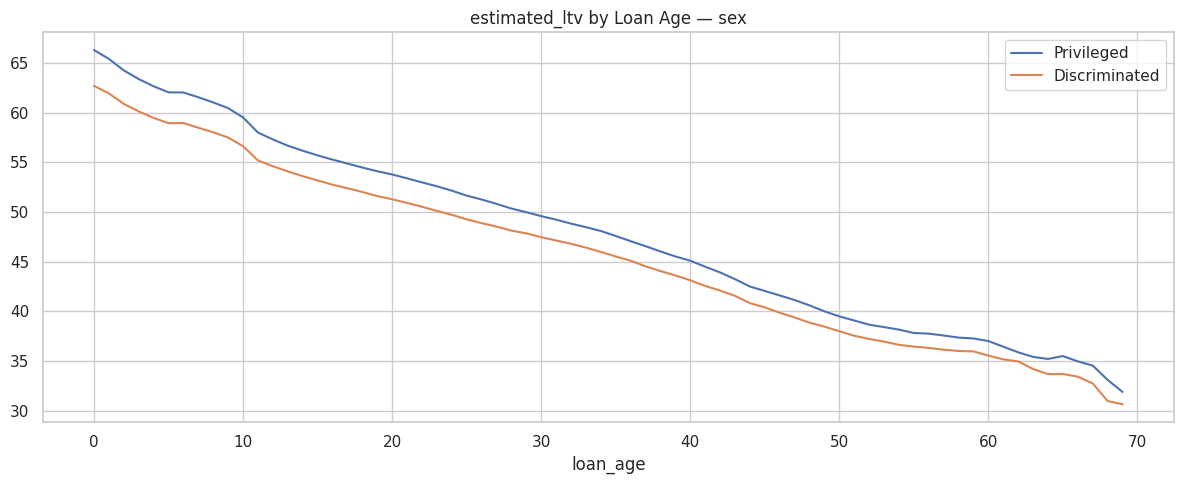

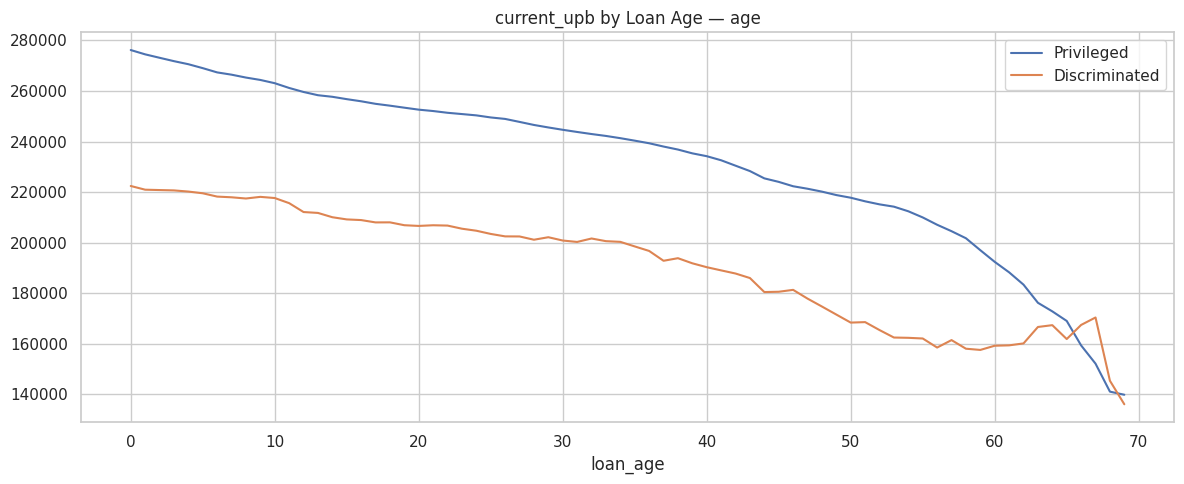

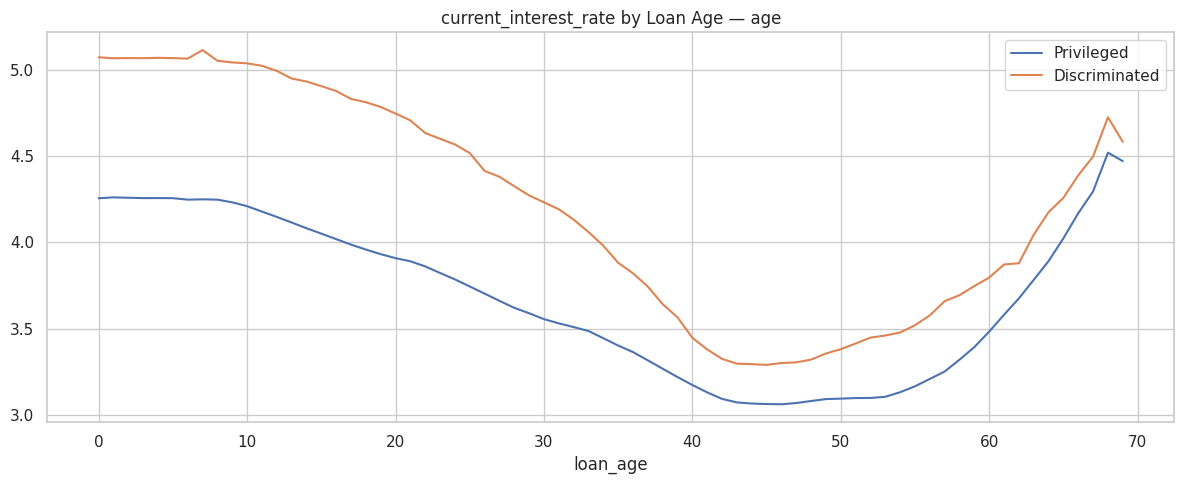

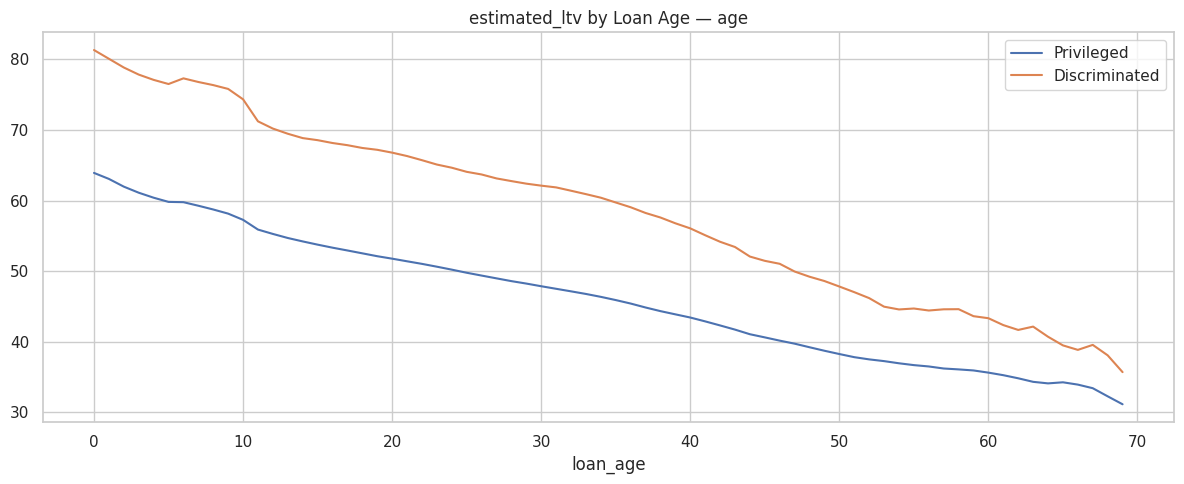

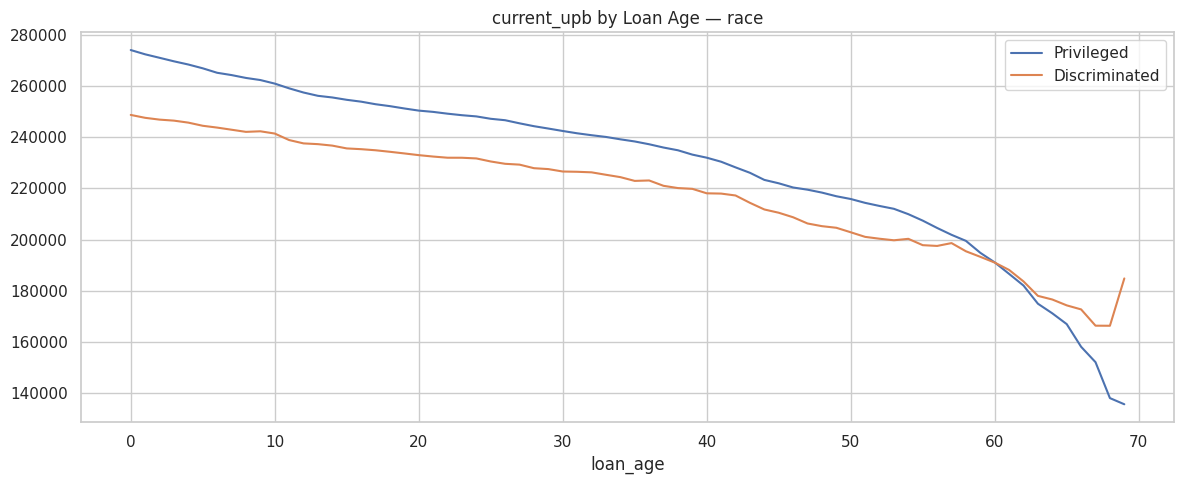

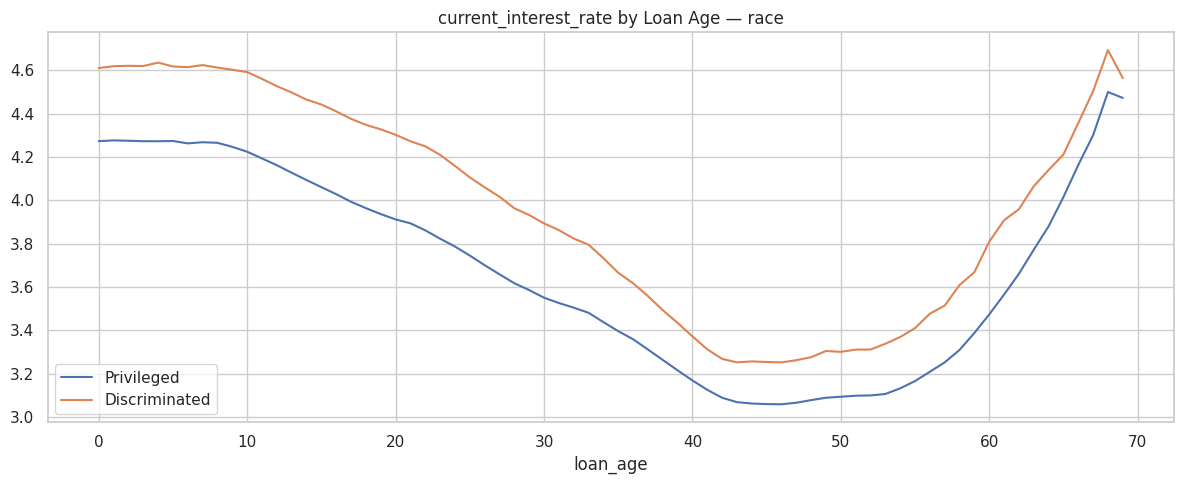

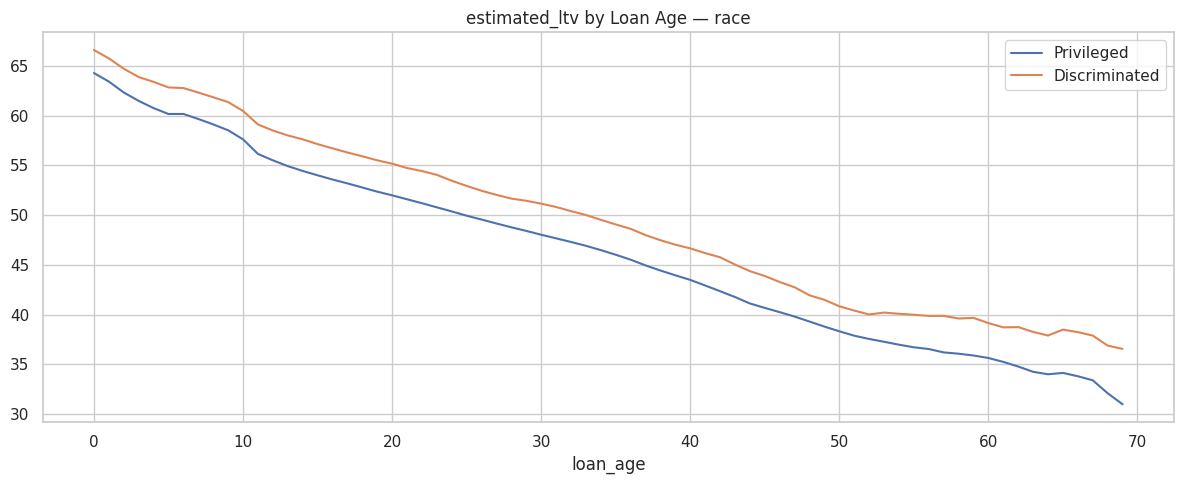

In [48]:
demo_cols=["sex_bin_loan", "age_bin_loan", "race_bin_loan",]

for demo in demo_cols:
  for col in tvc_cols:
      fig, ax = plt.subplots(figsize=(12, 5))
      for val, label in [(0, "Privileged"), (1, "Discriminated")]:
          mask = df[demo] == val
          df[mask].groupby("loan_age")[col].mean().plot(ax=ax, label=label)
      ax.set_title(f"{col} by Loan Age — {demo.split("_")[0]}")
      ax.legend()
      plt.tight_layout()

Minority and Young borrowers show higher estimated_ltv and lower current_upb
trajectories across loan age, suggesting slower equity accumulation compared
to privileged groups. These differences persist over time and are not
fully explained by origination characteristics, indicating dynamic disparities
captured only by the landmark model.

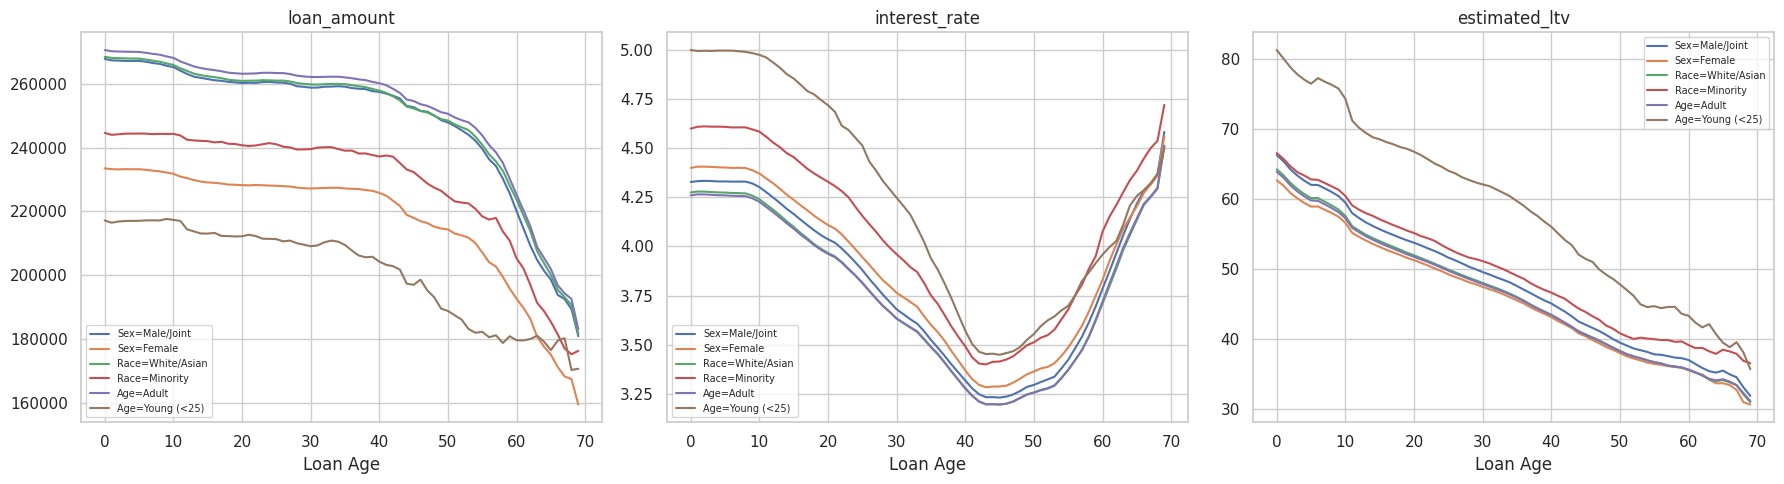

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for demo_col, demo_labels, title in [
    ("sex_bin_loan",  {0: "Male/Joint", 1: "Female"},       "Sex"),
    ("race_bin_loan", {0: "White/Asian", 1: "Minority"}, "Race"),
    ("age_bin_loan",  {0: "Adult", 1: "Young (<25)"},  "Age"),
]:
    for val, label in demo_labels.items():
        mask = df[demo_col] == val
        for ax, col in zip(axes, ["loan_amount", "interest_rate", "estimated_ltv"]):
            df[mask].groupby("loan_age")[col].mean().plot(ax=ax, label=f"{title}={label}")

for ax, col in zip(axes, ["loan_amount", "interest_rate", "estimated_ltv"]):
    ax.set_title(col)
    ax.set_xlabel("Loan Age")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

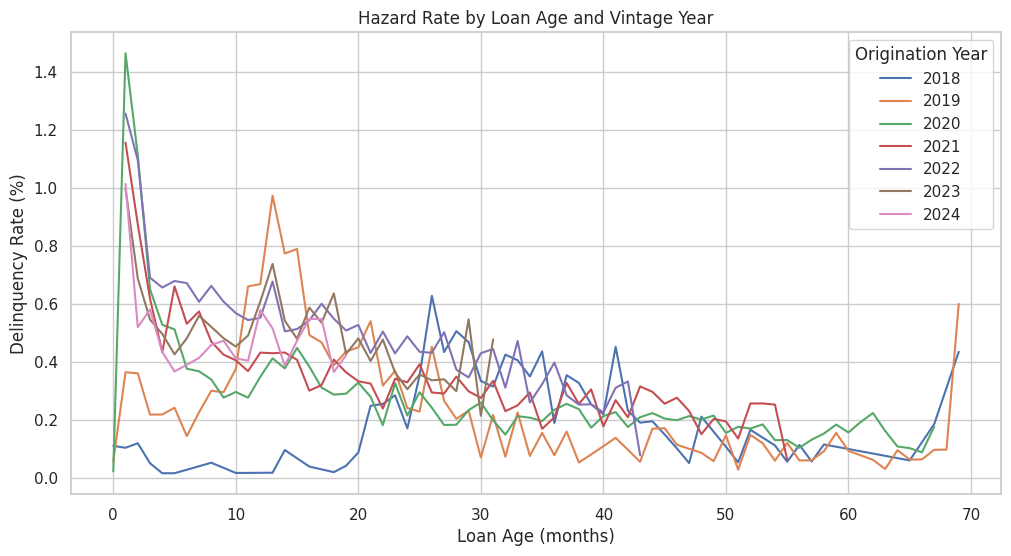

In [66]:
df["vintage_year"] = ("20" + df["loan_sequence_number"].astype(str).str[1:3]).astype(int)

fig, ax = plt.subplots(figsize=(12, 6))
for year, group in df.groupby("vintage_year"):
    at_risk = group.groupby("loan_age")["loan_sequence_number"].count()
    events  = (group[group["FirstDefaultAge"] == group["loan_age"]]
               .groupby("loan_age")["loan_sequence_number"].count())
    (events / at_risk * 100).dropna().plot(ax=ax, label=str(year))
ax.set_title("Hazard Rate by Loan Age and Vintage Year")
ax.set_xlabel("Loan Age (months)")
ax.set_ylabel("Delinquency Rate (%)")
ax.legend(title="Origination Year")
plt.show()

**Survival Curve...**

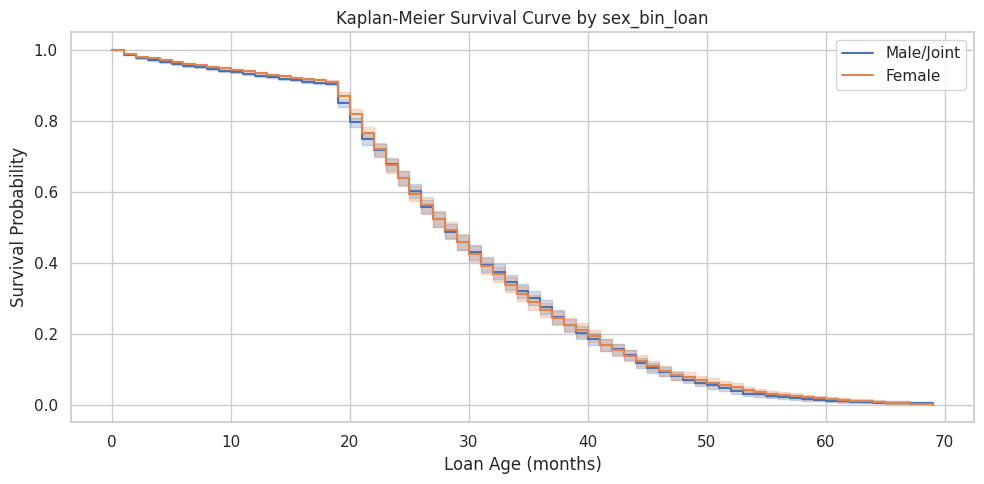

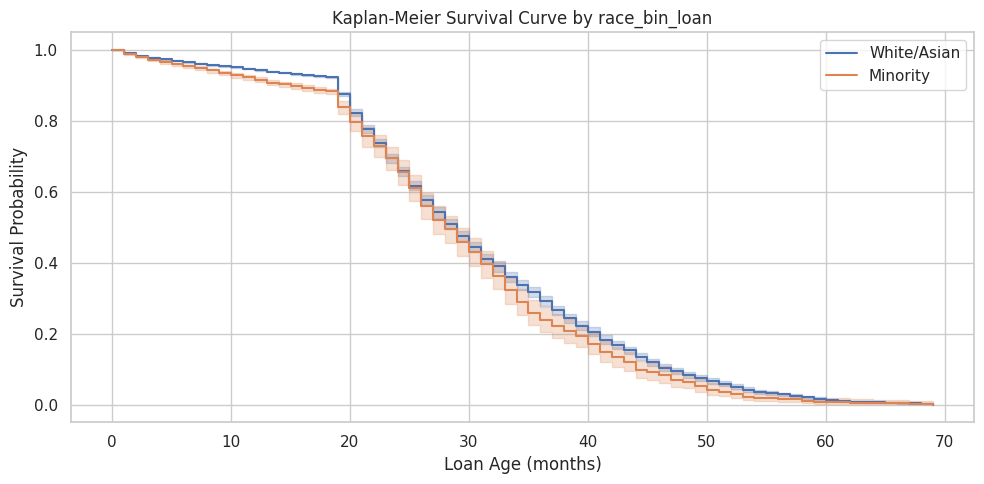

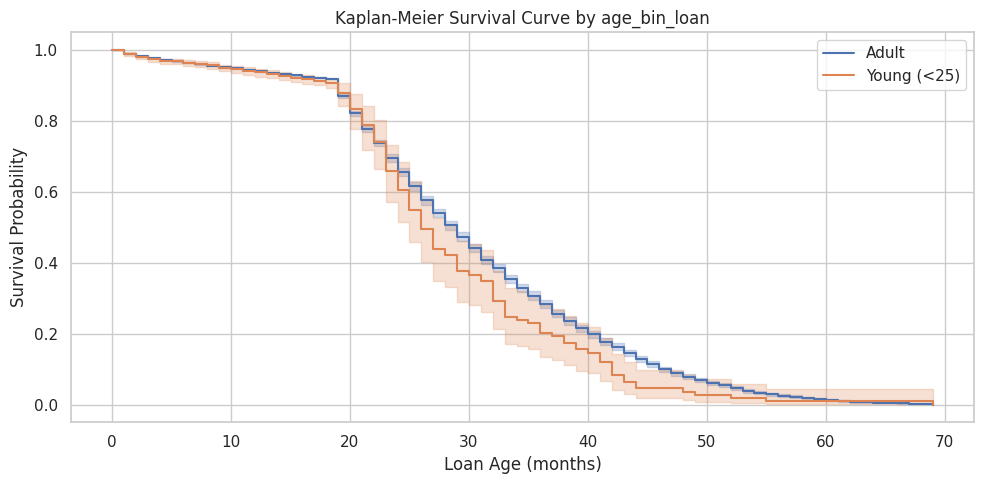

In [70]:
from lifelines import KaplanMeierFitter

snap = df.drop_duplicates("loan_sequence_number").copy()
snap["duration"] = snap["FirstDefaultAge"].fillna(snap["loan_age"].max())
snap["event"]    = snap["ever_default"]

for demo, labels in [
    ("sex_bin_loan",  {0: "Male/Joint", 1: "Female"}),
    ("race_bin_loan", {0: "White/Asian", 1: "Minority"}),
    ("age_bin_loan",  {0: "Adult",       1: "Young (<25)"}),
]:
    fig, ax = plt.subplots(figsize=(10, 5))

    for val, label in labels.items():
        sub = snap[snap[demo] == val].dropna(subset=[demo])
        kmf = KaplanMeierFitter()
        kmf.fit(sub["duration"], event_observed=sub["event"], label=label)
        kmf.plot_survival_function(ax=ax, ci_show=True)

    ax.set_title(f"Kaplan-Meier Survival Curve by {demo}")
    ax.set_xlabel("Loan Age (months)")
    ax.set_ylabel("Survival Probability")
    ax.legend()
    plt.tight_layout()
    plt.show()

KM curves show statistically significant differences across all three
demographic attributes: Minority and Young borrowers have lower
survival probability at every loan age. Sex, however, shows a more balanced pattern — Male/Joint
and Female curves are closer together and confidence intervals overlap for most
of the loan life, suggesting that gender alone is a weaker predictor of default
in this dataset. This heterogeneity across demographic attributes motivates
evaluating fairness separately for SEX, RACE, and AGE in the experimental analysis.